# Segmentation et Extraction de Contours

Ce notebook couvre:
- Detection de zones de texture anormale avec Sobel et Canny
- Isolation de la feuille du fond
  - Seuillage
  - Segmentation couleur HSV
  - Segmentation par clustering K-Means
- Comparaison subjective des resultats

In [11]:
from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print('Imports OK')

Imports OK


In [12]:
# Configuration
INPUT_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../results/segmentation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESIZE_TO = (512, 512)
RANDOM_SEED = 100
SAMPLE_INDEX = 0  # changer cet index pour tester une autre image
SAMPLES_PER_FOLDER = 3  # nombre d'images par dossier à tester en batch

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

print(f'Input dir: {INPUT_DIR.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')

Input dir: C:\Users\louay\OneDrive\Desktop\computer vision\data\raw
Output dir: C:\Users\louay\OneDrive\Desktop\computer vision\results\segmentation


In [ ]:
def list_images(root: Path):
    """Return a sorted list of image file Paths under `root`.
    Scans recursively and filters by `VALID_EXTENSIONS` for determinism."""
    return sorted([p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS])


def load_sample_image(image_paths, index=0, resize_to=(512, 512)):
    """Load a single image and return multiple representations.
    Returns: (image_path, image_bgr, image_rgb, image_gray, image_hsv).
    - validates non-empty list, clamps index, reads with OpenCV and resizes."""
    if not image_paths:
        raise RuntimeError(f'No images found in: {INPUT_DIR.resolve()}')

    index = max(0, min(index, len(image_paths) - 1))
    image_path = image_paths[index]

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise RuntimeError(f'Cannot read image: {image_path}')

    image_bgr = cv2.resize(image_bgr, resize_to, interpolation=cv2.INTER_AREA)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    return image_path, image_bgr, image_rgb, image_gray, image_hsv


def show_images(titles, images, cmap_list=None, figsize=(16, 8)):
    """Display multiple images side-by-side using matplotlib.
    - `titles`: list of subplot titles.
    - `images`: list of images (RGB arrays or single-channel arrays).
    - `cmap_list`: optional per-image colormaps (e.g. 'gray')."""
    if cmap_list is None:
        cmap_list = [None] * len(images)

    cols = len(images)
    plt.figure(figsize=figsize)
    for i, (title, img, cmap) in enumerate(zip(titles, images, cmap_list), start=1):
        plt.subplot(1, cols, i)
        if cmap is None:
            plt.imshow(img)
        else:
            plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Mask refinement helpers ---
def clean_mask(mask, kernel_size=5, min_area_ratio=0.01):
    """Refine a binary mask by morphology and largest-component filtering.
    Steps: morphology open/close, keep largest connected component, fill holes.
    If the largest component is too small (relative to image), return the original mask."""
    if mask is None:
        return None
    if mask.dtype != np.uint8:
        mask = (mask > 0).astype(np.uint8) * 255
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_idx = int(np.argmax(areas)) + 1
    final = np.zeros_like(mask)
    final[labels == max_idx] = 255
    # fill holes using contours
    contours, _ = cv2.findContours(final.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_filled = np.zeros_like(final)
    cv2.drawContours(mask_filled, contours, -1, 255, thickness=cv2.FILLED)
    img_area = mask.size
    if areas[max_idx-1] < min_area_ratio * img_area:
        return mask
    return mask_filled

def apply_grabcut(image_rgb, init_mask, iter_count=5):
    """Refine a binary mask using GrabCut initialized from `init_mask`.
    `init_mask` should be a binary (uint8) mask where foreground pixels are non-zero.
    Returns the refined binary mask or the original mask on failure."""
    if init_mask is None:
        return None
    if init_mask.dtype != np.uint8:
        init_mask = (init_mask > 0).astype(np.uint8) * 255
    gc_mask = np.where(init_mask == 255, cv2.GC_PR_FGD, cv2.GC_PR_BGD).astype('uint8')
    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    try:
        cv2.grabCut(image_rgb, gc_mask, None, bgdModel, fgdModel, iter_count, cv2.GC_INIT_WITH_MASK)
        res = np.where((gc_mask==cv2.GC_FGD) | (gc_mask==cv2.GC_PR_FGD), 255, 0).astype('uint8')
        return res
    except Exception:
        return init_mask

def segment_leaf(image_rgb, image_gray, image_hsv, n_clusters=3, kernel_size=5, grabcut_iter=5):
    """Combine Otsu, HSV thresholding and KMeans clustering to segment a leaf.
    Pipeline overview:
      1) Otsu thresholding on grayscale to separate foreground by intensity.
      2) HSV thresholding to detect green hues (configurable bounds).
      3) KMeans clustering in LAB space to robustly separate color clusters.
      4) Logical OR of masks, then morphological cleaning and largest-component selection.
      5) If cleaned mask is too small, use GrabCut as a fallback.
    Returns a dict with intermediate masks and the final refined mask for inspection."""
    # Otsu
    _, mask_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(mask_otsu) > 127:
        mask_otsu = cv2.bitwise_not(mask_otsu)
    # HSV
    mask_hsv = cv2.inRange(image_hsv, lower_green, upper_green)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_OPEN, kernel)
    mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_CLOSE, kernel)
    # KMeans in LAB space for color stability
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    pixels = lab.reshape((-1,3)).astype(np.float32)
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(pixels)
    centers_lab = kmeans.cluster_centers_.astype(np.uint8)
    # convert centers back to RGB to compute green score
    centers_lab_img = centers_lab.reshape(1, -1, 3)
    centers_rgb = cv2.cvtColor(centers_lab_img, cv2.COLOR_LAB2RGB).reshape(-1,3)
    green_score = centers_rgb[:,1] - (centers_rgb[:,0] + centers_rgb[:,2]) / 2
    leaf_cluster = int(np.argmax(green_score))
    mask_kmeans = (labels.reshape(image_rgb.shape[:2]) == leaf_cluster).astype(np.uint8) * 255
    mask_kmeans = cv2.morphologyEx(mask_kmeans, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    # combine masks and clean
    combined = cv2.bitwise_or(mask_hsv, mask_otsu)
    combined = cv2.bitwise_or(combined, mask_kmeans)
    cleaned = clean_mask(combined, kernel_size=kernel_size)
    # if cleaned is too small, try grabcut to recover the leaf
    img_area = cleaned.size
    if cleaned.sum() < 0.01 * img_area * 255:
        grab = apply_grabcut(image_rgb, cleaned, iter_count=grabcut_iter)
        final = clean_mask(grab, kernel_size=kernel_size)
    else:
        final = cleaned
    leaf_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=final)
    return {
        'mask_otsu': mask_otsu,
        'mask_hsv': mask_hsv,
        'mask_kmeans': mask_kmeans,
        'combined': combined,
        'refined': final,
        'leaf_refined': leaf_rgb,
        'kmeans_centers_rgb': centers_rgb,
        'leaf_cluster': leaf_cluster
    }

Image choisie: ..\data\raw\Pepper__bell___Bacterial_spot\0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG


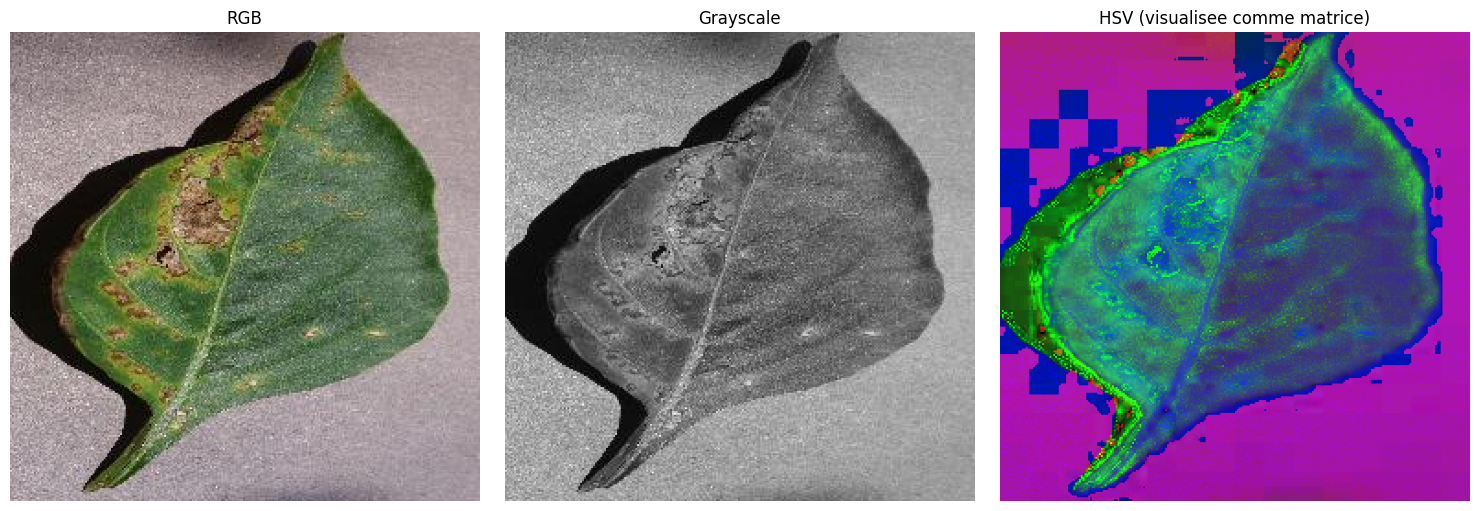

In [14]:
# Chargement de l'image exemple
np.random.seed(RANDOM_SEED)
image_paths = list_images(INPUT_DIR)

if not image_paths:
    raise FileNotFoundError('Aucune image trouvee dans data/raw. Ajoutez des images par classe.')

img_path, img_bgr, img_rgb, img_gray, img_hsv = load_sample_image(
    image_paths, index=SAMPLE_INDEX, resize_to=RESIZE_TO
)

print(f'Image choisie: {img_path}')
show_images(
    ['RGB', 'Grayscale', 'HSV (visualisee comme matrice)'],
    [img_rgb, img_gray, img_hsv],
    [None, 'gray', None],
    figsize=(15, 5)
)

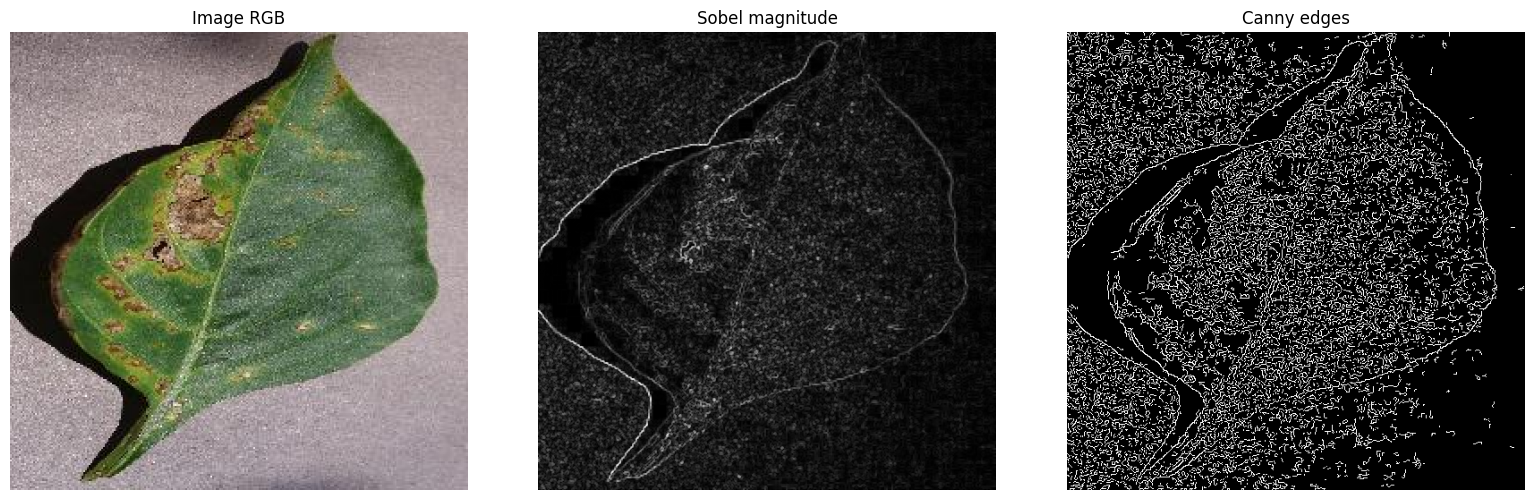

In [15]:
# 1) Extraction de contours: Sobel et Canny
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)
sobel_mag = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

canny_edges = cv2.Canny(img_gray, threshold1=70, threshold2=150)

show_images(
    ['Image RGB', 'Sobel magnitude', 'Canny edges'],
    [img_rgb, sobel_mag, canny_edges],
    [None, 'gray', 'gray'],
    figsize=(16, 5)
)

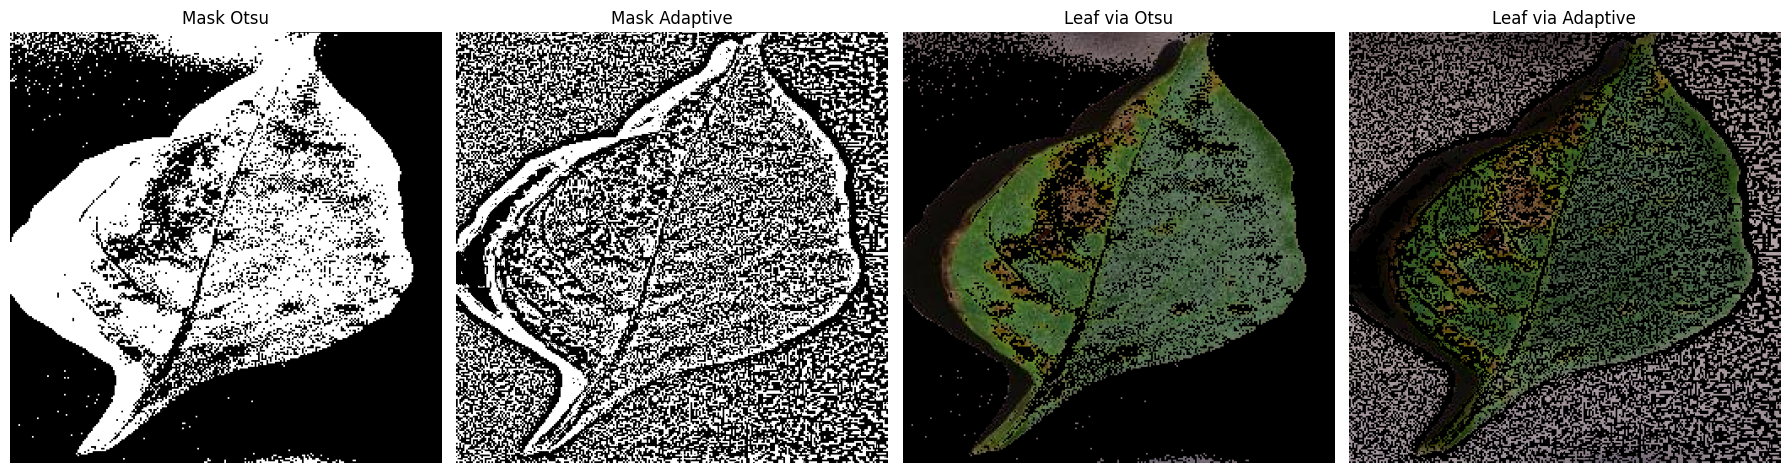

In [16]:
# 2) Segmentation par seuillage (Otsu + adaptive)
_, mask_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
mask_adaptive = cv2.adaptiveThreshold(
    img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 35, 2
)

# Option: inverser les masques si la feuille est en noir
if np.mean(mask_otsu) > 127:
    mask_otsu = cv2.bitwise_not(mask_otsu)
if np.mean(mask_adaptive) > 127:
    mask_adaptive = cv2.bitwise_not(mask_adaptive)

leaf_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_otsu)
leaf_adaptive = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_adaptive)

show_images(
    ['Mask Otsu', 'Mask Adaptive', 'Leaf via Otsu', 'Leaf via Adaptive'],
    [mask_otsu, mask_adaptive, leaf_otsu, leaf_adaptive],
    ['gray', 'gray', None, None],
    figsize=(18, 6)
)

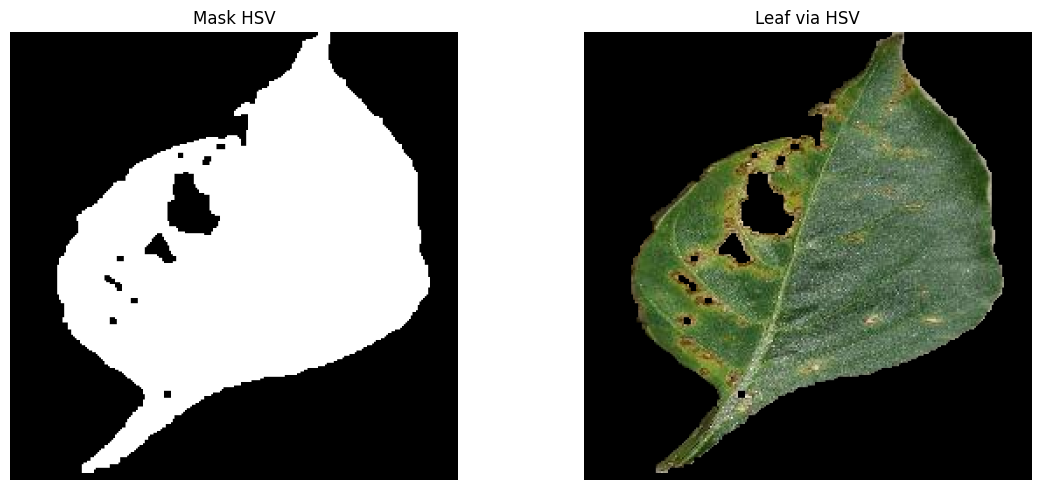

In [17]:
# 3) Segmentation couleur HSV
# Ajuster ces bornes selon votre dataset (PlantVillage, fond variable, etc.)
lower_green = np.array([20, 30, 30], dtype=np.uint8)
upper_green = np.array([95, 255, 255], dtype=np.uint8)

mask_hsv = cv2.inRange(img_hsv, lower_green, upper_green)
kernel = np.ones((5, 5), np.uint8)
mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_OPEN, kernel)
mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_CLOSE, kernel)

leaf_hsv = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hsv)

show_images(
    ['Mask HSV', 'Leaf via HSV'],
    [mask_hsv, leaf_hsv],
    ['gray', None],
    figsize=(12, 5)
)

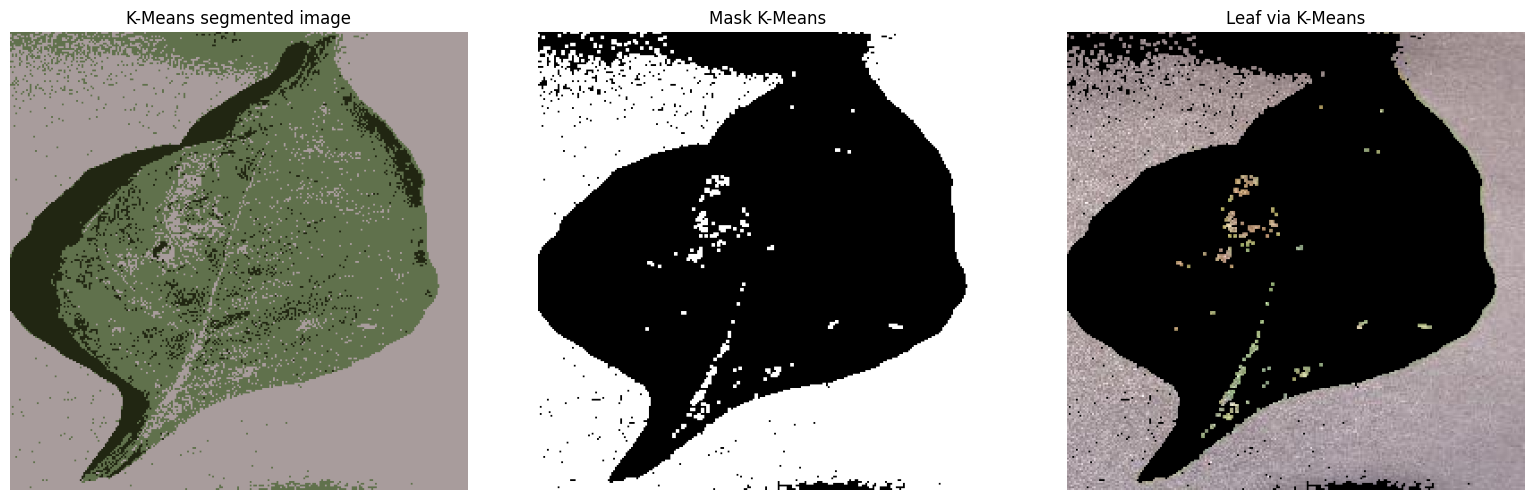

Cluster centers (RGB):
[[ 96 113  76]
 [168 156 156]
 [ 33  38  18]]
Leaf cluster selected: 1


In [ ]:
# 4) Segmentation par clustering K-Means (combined + refinement)
n_clusters = 3

# Use the helper that combines Otsu, HSV and KMeans and refines the mask
seg_results = segment_leaf(img_rgb, img_gray, img_hsv, n_clusters=n_clusters, kernel_size=5, grabcut_iter=5)

# Try to get KMeans centers for diagnostic output (may be None in fallback)
centers_rgb = None
try:
    centers_rgb = np.clip(seg_results['kmeans_centers_rgb'], 0, 255).astype(np.uint8)
except Exception:
    centers_rgb = None

show_images(
    ['Original', 'Mask Otsu', 'Mask HSV', 'Mask KMeans', 'Combined', 'Refined Leaf'],
    [img_rgb, seg_results['mask_otsu'], seg_results['mask_hsv'], seg_results['mask_kmeans'], seg_results['combined'], seg_results['leaf_refined']],
    [None, 'gray', 'gray', 'gray', 'gray', None],
    figsize=(20, 6)
)

print('Leaf cluster selected (KMeans):', seg_results['leaf_cluster'])
if centers_rgb is not None:
    print('KMeans centers (approx RGB):')
    print(centers_rgb)

# Export variables for downstream cells
mask_otsu = seg_results['mask_otsu']
mask_hsv = seg_results['mask_hsv']
mask_kmeans = seg_results['mask_kmeans']
mask_combined = seg_results['combined']
mask_refined = seg_results['refined']
leaf_refined = seg_results['leaf_refined']
leaf_cluster = int(seg_results['leaf_cluster'])

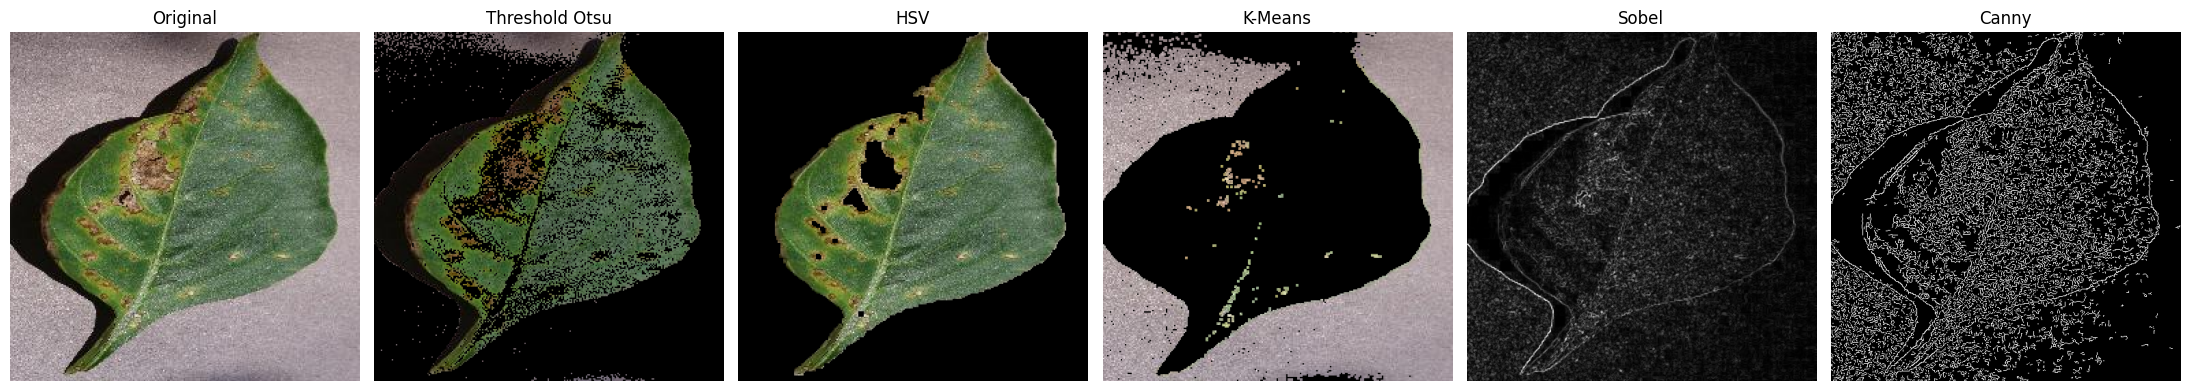

Comparaison subjective sauvegardee: C:\Users\louay\OneDrive\Desktop\computer vision\results\segmentation\subjective_comparison.json


{'image': '..\\data\\raw\\Pepper__bell___Bacterial_spot\\0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG',
 'subjective_observations': {'thresholding': 'A remplir: qualite de separation feuille/fond, sensibilite au bruit.',
  'hsv': 'A remplir: qualite sur zones vertes, erreurs sur ombres/reflets.',
  'kmeans': 'A remplir: robustesse couleurs, zones mal classees.',
  'sobel_canny': 'A remplir: pertinence des contours et zones anormales detectees.'},
 'best_method_for_background_removal': 'A remplir',
 'best_method_for_texture_anomaly_hint': 'A remplir'}

In [ ]:
# 5) Comparaison subjective des resultats
show_images(
    ['Original', 'Threshold Otsu', 'HSV', 'K-Means', 'Combined', 'Refined'],
    [img_rgb, mask_otsu, mask_hsv, mask_kmeans, mask_combined, mask_refined],
    [None, 'gray', 'gray', 'gray', 'gray', 'gray'],
    figsize=(22, 8)
)

def mask_stats(mask):
    """Compute simple statistics for a binary mask.
    Returns a dict with keys: 'area', 'area_fraction', and 'n_contours'."""
    if mask is None:
        return {'area': 0, 'area_fraction': 0.0, 'n_contours': 0}
    bin_mask = (mask > 0).astype(np.uint8)
    area = int(bin_mask.sum())
    area_frac = area / mask.size
    contours, _ = cv2.findContours(bin_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return {'area': area, 'area_fraction': float(area_frac), 'n_contours': int(len(contours))}

automated_observations = {
    'otsu': mask_stats(mask_otsu),
    'hsv': mask_stats(mask_hsv),
    'kmeans': mask_stats(mask_kmeans),
    'combined': mask_stats(mask_combined),
    'refined': mask_stats(mask_refined)
}

comparison_notes = {
    'image': str(img_path),
    'subjective_observations': {
        'thresholding': 'Qualite: depends sur contraste; sensible au bruit et eclairages.',
        'hsv': 'Qualite: detecte zones vertes, sensible a ombres/reflets.',
        'kmeans': 'Qualite: capture couleurs, peut fragmenter la feuille.',
        'combined': 'Qualite: union des methodes, plus complet mais bruyant avant nettoyage.',
        'refined': 'Qualite: masque final nettoye (morphologie + plus grand composant), trous remplis.',
    },
    'automated_observations': automated_observations,
    'best_method_for_background_removal': 'refined',
    'explanation': 'Refined mask keeps the largest connected component, removes small noisy components and uses GrabCut fallback when the combined mask is too small.'
}

notes_path = OUTPUT_DIR / 'subjective_comparison.json'
notes_path.write_text(json.dumps(comparison_notes, indent=2), encoding='utf-8')
print(f'Comparaison sauvegardee: {notes_path.resolve()}')
comparison_notes

In [ ]:
# 6) Export des sorties principales
base_name = Path(img_path).stem

# Save masks (including combined and refined)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_mask_otsu.png'), mask_otsu)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_mask_hsv.png'), mask_hsv)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_mask_kmeans.png'), mask_kmeans)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_mask_combined.png'), mask_combined)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_mask_refined.png'), mask_refined)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_sobel.png'), sobel_mag)
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_canny.png'), canny_edges)

cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_leaf_otsu.png'), cv2.cvtColor(leaf_otsu, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_leaf_hsv.png'), cv2.cvtColor(leaf_hsv, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_leaf_kmeans.png'), cv2.cvtColor(leaf_kmeans, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / f'{base_name}_leaf_refined.png'), cv2.cvtColor(leaf_refined, cv2.COLOR_RGB2BGR))

summary = {
    'image': str(img_path),
    'resize_to': list(RESIZE_TO),
    'n_clusters': n_clusters,
    'leaf_cluster': leaf_cluster,
    'output_dir': str(OUTPUT_DIR.resolve())
}

summary_path = OUTPUT_DIR / f'{base_name}_segmentation_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Exports termines:')
print(f'- Dossier resultats: {OUTPUT_DIR.resolve()}')
print(f'- Resume JSON: {summary_path.resolve()}')
# Batch: up to SAMPLES_PER_FOLDER examples from each image folder (class)
# Find all folders that contain images and pick up to SAMPLES_PER_FOLDER samples per folder
folders = sorted({p.parent for p in list_images(INPUT_DIR)})
if not folders:
    raise FileNotFoundError('No image folders found under INPUT_DIR')

batch_summary = []
for folder in folders:
    imgs = [p for p in sorted(folder.iterdir()) if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]
    if not imgs:
        continue
    samples = imgs[:SAMPLES_PER_FOLDER]
    for sample_idx, img_path in enumerate(samples, start=1):
        try:
            print(f'Processing folder: {folder} -> sample {sample_idx}: {img_path}')
            image_bgr = cv2.imread(str(img_path))
            if image_bgr is None:
                print(f'Cannot read {img_path}, skipping')
                continue
            image_bgr = cv2.resize(image_bgr, RESIZE_TO, interpolation=cv2.INTER_AREA)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
            image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

            # Sobel & Canny
            sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
            sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
            sobel_mag = cv2.magnitude(sobel_x, sobel_y)
            sobel_mag = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            canny_edges = cv2.Canny(image_gray, 70, 150)

            # Use helper segmenter to compute masks + refined result
            seg_results = segment_leaf(image_rgb, image_gray, image_hsv, n_clusters=n_clusters)
            mask_otsu = seg_results['mask_otsu']
            mask_hsv = seg_results['mask_hsv']
            mask_kmeans = seg_results['mask_kmeans']
            mask_combined = seg_results['combined']
            mask_refined = seg_results['refined']
            leaf_otsu = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_otsu)
            leaf_hsv = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_hsv)
            leaf_kmeans = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_kmeans)
            leaf_refined = seg_results['leaf_refined']

            # Save outputs
            base = f'{folder.name}_{Path(img_path).stem}_{sample_idx}'
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_mask_otsu.png'), mask_otsu)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_mask_hsv.png'), mask_hsv)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_mask_kmeans.png'), mask_kmeans)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_mask_combined.png'), mask_combined)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_mask_refined.png'), mask_refined)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_sobel.png'), sobel_mag)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_canny.png'), canny_edges)
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_leaf_otsu.png'), cv2.cvtColor(leaf_otsu, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_leaf_hsv.png'), cv2.cvtColor(leaf_hsv, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_leaf_kmeans.png'), cv2.cvtColor(leaf_kmeans, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(OUTPUT_DIR / f'{base}_leaf_refined.png'), cv2.cvtColor(leaf_refined, cv2.COLOR_RGB2BGR))

            # record a compact summary for this sample
            area_refined = int((mask_refined > 0).astype(np.uint8).sum())
            area_frac = float(area_refined) / mask_refined.size if mask_refined is not None else 0.0
            batch_summary.append({'folder': str(folder), 'sample': str(img_path), 'leaf_cluster': int(seg_results.get('leaf_cluster', -1)), 'refined_area_fraction': area_frac})
        except Exception as e:
            print(f'Error processing {img_path}: {e}')

summary_path = OUTPUT_DIR / 'one_per_folder_summary.json'
summary_path.write_text(json.dumps(batch_summary, indent=2), encoding='utf-8')
print(f'Batch processing (up to {SAMPLES_PER_FOLDER} per folder) complete. Results saved to {OUTPUT_DIR.resolve()}')

Exports termines:
- Dossier resultats: C:\Users\louay\OneDrive\Desktop\computer vision\results\segmentation
- Resume JSON: C:\Users\louay\OneDrive\Desktop\computer vision\results\segmentation\0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964_segmentation_summary.json
Processing folder: ..\data\raw\Pepper__bell___Bacterial_spot -> sample 1: ..\data\raw\Pepper__bell___Bacterial_spot\0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG
Processing folder: ..\data\raw\Pepper__bell___Bacterial_spot -> sample 2: ..\data\raw\Pepper__bell___Bacterial_spot\006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG
Processing folder: ..\data\raw\Pepper__bell___Bacterial_spot -> sample 3: ..\data\raw\Pepper__bell___Bacterial_spot\00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG
Processing folder: ..\data\raw\Pepper__bell___healthy -> sample 1: ..\data\raw\Pepper__bell___healthy\00100ffa-095e-4881-aebf-61fe5af7226e___JR_HL 7886.JPG
Processing folder: ..\data\raw\Pepper__bell___heal

## Conseils de comparaison subjective

Pour chaque methode, notez par exemple:
- Qualite de separation feuille/fond
- Sensibilite au bruit
- Stabilite face aux ombres et variations de lumiere
- Capacite a conserver les details utiles (bords, zones tachees)

Puis justifiez la methode retenue selon votre objectif (segmentation feuille ou detection d'anomalies).

**Conclusion**

- **Ce qui a été implémenté :** Combinaison d'Otsu, seuillage HSV et KMeans, nettoyage morphologique et fallback GrabCut pour segmenter robustement les feuilles sur fonds variés.
- **Quand utiliser chaque méthode :** Otsu pour images à fort contraste, HSV pour séparation par teinte verte, KMeans pour séparation basée sur la couleur quand l'éclairage varie.
- **Points forts :** L'approche combinée augmente le rappel des régions de feuille et réduit les cas d'échec ; `clean_mask` conserve le composant le plus probable et comble les trous.
- **Limites :** Sensible aux feuilles non-vertes, aux ombres sévères ou aux fonds très encombrés ; les paramètres (`lower_green`, `upper_green`, `n_clusters`, `kernel_size`) peuvent nécessiter un ajustement par dataset.
- **Étapes suivantes :** Ajuster les bornes HSV par dataset, évaluer quantitativement sur masques annotés, envisager la segmentation par deep learning (U-Net / Mask R-CNN) pour les scénarios difficiles.

Fin du notebook.